In [31]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
# Load the dataset
dataset = pd.read_csv("/content/bmi.csv")
dataset

,bmi,class
0,23.52,0
1,28.88,1
2,31.96,1
3,21.12,0
4,22.61,0
...,...,...
495,37.35,1
496,24.29,0
497,30.26,1
498,23.93,0


In [33]:
# Separate the columns into x (bmi) and y (class/category)
x = dataset.iloc[:, [0]]
y = dataset.iloc[:, [1]]

Text(0.5, 1.0, 'BMI vs Category Scatter Plot')

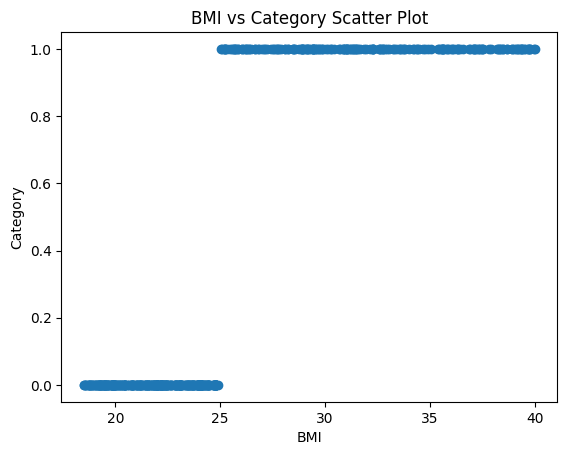

In [34]:
# Plot the scatter plot
plt.scatter(x,y)
plt.xlabel('BMI')
plt.ylabel('Category')
plt.title("BMI vs Category Scatter Plot")

In [35]:
# Linear regression
def hypothesis(theta_array,x):
  return theta_array[0] + theta_array[1] * x

def cost_function(theta_array,x,y,m):
  errors = 0
  for i in range(m):
    errors = errors + ((theta_array[0] + theta_array[1] * x[i]) - y[i]) ** 2
  return errors / (2*m)


# Gradient Descent Approach
def gradient_descent(theta_array,x,y,m,alpha):
  summation_0 = 0
  summation_1 = 0
  for i in range(m):
    summation_0 = summation_0 + (theta_array[0] + theta_array[1] * x[i]) - y[i]
    summation_1 = summation_1 + ((theta_array[0] + theta_array[1] * x[i]) - y[i]) * x[i]

  new_theta0 = theta_array[0] - (alpha/m) * summation_0
  new_theta1 = theta_array[1] - (alpha/m) * summation_1
  updated_new_theta = [new_theta0,new_theta1]
  return updated_new_theta


# Training function
def training(x,y,alpha,iterations):
  theta0 = 0
  theta1 = 0
  theta_array = [theta0,theta1]
  m = x.size
  cost_values = []

  for i in range(iterations):
    theta_array = gradient_descent(theta_array,x,y,m,alpha)
    cost_values.append(cost_function(theta_array,x,y,m))
    y_predict = hypothesis(theta_array, x)
    # Plotting code - removed plt.show() from loop, fixed axis and labels
    plt.plot(x,y_predict,'r') # x as independent, y_predict as dependent
    plt.scatter(x,y)          # x as independent, y as dependent
    plt.xlabel("Scaled BMI")
    plt.ylabel("Category (0='under/normal', 1='overweight/obese')")
    # plt.show() # Removed this from the loop

  return cost_values, theta_array

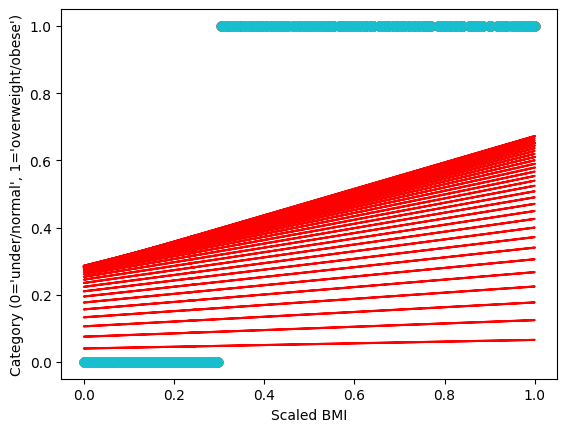

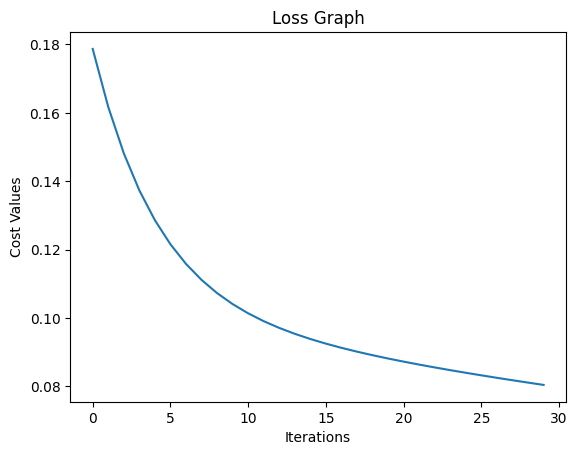

[np.float64(0.27942669202530335), np.float64(0.39280217050381827)]


In [36]:
# Convert our data into numpy arrays (moved from yx-hXaohxQlF)
x_value = x.values.reshape(x.size)
y_value = y.values.reshape(y.size)

# Scale down the height from 0 to 1 (moved from YTwZXTJuVwnQ)
x_min, x_max = x_value.min(), x_value.max()
x_value = (x_value - x_min) / (x_max - x_min)

# Start the training
alpha = 0.1
iterations = 30
cost_values, theta_array = training(x_value, y_value, alpha, iterations)
plt.show() # Display the regression plot generated during training

x_axis = np.arange(0, len(cost_values), step=1)
plt.plot(x_axis,cost_values)
plt.xlabel("Iterations")
plt.ylabel("Cost Values")
plt.title("Loss Graph")
plt.show() # Display the loss graph
print(theta_array)

In [37]:
# Function to get the label
def predict_label(theta_array, x, x_min, x_max, threshold=0.5):
    y = theta_array[0] + theta_array[1] * ((x - x_min) / (x_max - x_min))
    return 1 if y >= threshold else 0

In [38]:
# Test the model with BMI values
# Using BMI values 20 (normal) and 35 (obese) as examples
predict_low_bmi = predict_label(theta_array, 20.0, x_min, x_max)
predict_high_bmi = predict_label(theta_array, 35.0, x_min, x_max)
print(f"Prediction for BMI 20.0: {predict_low_bmi} (0='under/normal', 1='overweight/obese')")
print(f"Prediction for BMI 35.0: {predict_high_bmi} (0='under/normal', 1='overweight/obese')")

Prediction for BMI 20.0: 0 (0='under/normal', 1='overweight/obese')
Prediction for BMI 35.0: 1 (0='under/normal', 1='overweight/obese')


In [39]:
# Calculate the BMI threshold for class 0/1 transition
# y = theta_0 + theta_1 * scaled_x
# For y = 0.5 (threshold)
scaled_threshold_x = (0.5 - theta_array[0]) / theta_array[1]
bmi_threshold = scaled_threshold_x * (x_max - x_min) + x_min

# Test with a BMI just below the threshold
# Expected to be class 0
predict_label(theta_array, bmi_threshold - 0.01, x_min, x_max)

0

In [40]:
# Test with a BMI just above the threshold
# Expected to be class 1
predict_label(theta_array, bmi_threshold + 0.01, x_min, x_max)

1

## What changes should be done in the code of Multi-Variable Linear Regression?
In multivariable linear regression, all input variables are first normalized. When we convert the regression output into classes, we need to choose a threshold on the predicted output. Since the output depends on multiple normalized variables, the threshold is applied after normalization, based on the final predicted value.